In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.utils import AnalysisException

spark = (
    SparkSession.builder
    .appName("stn_0003")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "America/Toronto")
    # .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.10.0") \
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/03 17:03:22 WARN Utils: Your hostname, users-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.39 instead (on interface en0)
26/04/03 17:03:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 17:03:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/03 17:03:27 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
rides_path = "../../data/silver/rides"

try:
    rides_df = spark.read.parquet(rides_path)
except AnalysisException as e:
    raise RuntimeError(f"Could not read parquet dataset at {rides_path}: {e}")

schema_types = dict(rides_df.dtypes)

def as_timestamp(col_name: str):
    # Support either TIMESTAMP columns or epoch-milliseconds columns.
    if schema_types.get(col_name) == "timestamp":
        return F.col(col_name)
    return F.to_timestamp(F.from_unixtime((F.col(col_name).cast("double") / F.lit(1000.0))))

n_rows = rides_df.count()
n_cols = len(rides_df.columns)

summary_row = (
    rides_df
    .select(
        F.min(as_timestamp("start_time_ms")).alias("min_start_ts"),
        F.max(as_timestamp("start_time_ms")).alias("max_start_ts"),
        F.min(as_timestamp("end_time_ms")).alias("min_end_ts"),
        F.max(as_timestamp("end_time_ms")).alias("max_end_ts"),
        F.countDistinct("start_canonical_station_id").alias("n_start_stations"),
        F.countDistinct("end_canonical_station_id").alias("n_end_stations")
    )
    .collect()[0]
)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print("Column names:", rides_df.columns)
print("Quick summary:", summary_row)

print("\nSample rows (start/end time + canonical station IDs):")
rides_df.select(
    "start_time_ms",
    "end_time_ms",
    "start_canonical_station_id",
    "end_canonical_station_id"
).show(8, truncate=False)

Rows: 39,377,433
Columns: 19
Column names: ['end_station_key', 'start_station_key', 'start_station_name', 'start_station_district', 'start_station_latitude', 'start_station_longitude', 'end_station_name', 'end_station_district', 'end_station_latitude', 'end_station_longitude', 'start_time_ms', 'end_time_ms', 'start_station_name_norm', 'end_station_name_norm', 'start_coord_key', 'end_coord_key', 'start_canonical_station_id', 'end_canonical_station_id', 'ride_year']
Quick summary: Row(min_start_ts=datetime.datetime(2023, 4, 12, 23, 42, 44), max_start_ts=datetime.datetime(2026, 2, 1, 12, 58, 38), min_end_ts=datetime.datetime(2023, 4, 12, 23, 45, 57), max_end_ts=datetime.datetime(2026, 2, 7, 22, 28, 20), n_start_stations=1433, n_end_stations=1438)

Sample rows (start/end time + canonical station IDs):
+-------------------+-------------------+--------------------------+------------------------+
|start_time_ms      |end_time_ms        |start_canonical_station_id|end_canonical_station_id|
+--

Trips touching station STN_0003: 460,154
   trip_year  start_count  end_count  total_count
0       2023        70579      66836       137415
1       2024        84104      71076       155180
2       2025        96162      74950       171112
3       2026         1469       1116         2585


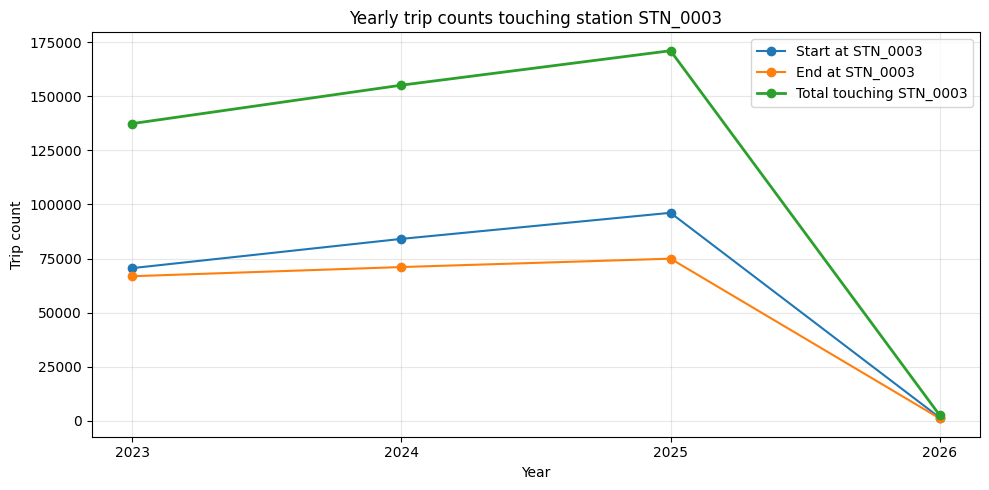

In [3]:
import matplotlib.pyplot as plt

TARGET_STATION = "STN_0003"

station_df = (
    rides_df
    .withColumn("trip_year", F.coalesce(F.col("ride_year"), F.year(F.col("start_time_ms"))))
    .filter(
        (F.col("start_canonical_station_id") == TARGET_STATION)
        | (F.col("end_canonical_station_id") == TARGET_STATION)
    )
    .cache()
)

print(f"Trips touching station {TARGET_STATION}:", f"{station_df.count():,}")

role_counts = (
    station_df
    .select(
        "trip_year",
        F.when(F.col("start_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("start_hit"),
        F.when(F.col("end_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("end_hit")
    )
    .groupBy("trip_year")
    .agg(
        F.sum("start_hit").alias("start_count"),
        F.sum("end_hit").alias("end_count")
    )
    .withColumn("total_count", F.col("start_count") + F.col("end_count"))
    .orderBy("trip_year")
)

role_counts_pd = role_counts.toPandas()
print(role_counts_pd)

# Treat year as categorical to show each year as a discrete value on x-axis.
year_labels = role_counts_pd["trip_year"].astype(int).astype(str)

plt.figure(figsize=(10, 5))
plt.plot(year_labels, role_counts_pd["start_count"], marker="o", label=f"Start at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["end_count"], marker="o", label=f"End at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["total_count"], marker="o", linewidth=2, label=f"Total touching {TARGET_STATION}")
plt.title(f"Yearly trip counts touching station {TARGET_STATION}")
plt.xlabel("Year")
plt.ylabel("Trip count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np

ANALYSIS_YEARS = [2023, 2024]

base_2023_2024 = (
    rides_df
    .filter(F.col("ride_year").isin(ANALYSIS_YEARS))
    .withColumn("trip_year", F.col("ride_year"))
)

outflow_df = (
    base_2023_2024
    .filter(F.col("start_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("start_time_ms").alias("event_ts"),
        F.lit("outflow").alias("direction"),
        F.col("end_canonical_station_id").alias("counterpart_station")
    )
)

inflow_df = (
    base_2023_2024
    .filter(F.col("end_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("end_time_ms").alias("event_ts"),
        F.lit("inflow").alias("direction"),
        F.col("start_canonical_station_id").alias("counterpart_station")
    )
)

flow_df = (
    outflow_df
    .unionByName(inflow_df)
    .filter(F.col("counterpart_station").isNotNull())
    .withColumn("month", F.month("event_ts"))
    .withColumn("day_of_week", F.date_format("event_ts", "E"))
    .withColumn("hour", F.hour("event_ts"))
    .cache()
)

annual_direction = (
    flow_df
    .groupBy("trip_year", "direction")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "direction")
)

annual_direction_pd = annual_direction.toPandas()
print("2023-2024 inflow/outflow totals")
print(annual_direction_pd)

pivot_annual = (
    annual_direction_pd
    .pivot(index="trip_year", columns="direction", values="trip_count")
    .fillna(0)
    .astype(int)
)
pivot_annual["total"] = pivot_annual.sum(axis=1)
print("\nAnnual totals table")
print(pivot_annual)

if len(pivot_annual.index) >= 2:
    years_sorted = sorted(pivot_annual.index.tolist())
    y0, y1 = years_sorted[0], years_sorted[1]
    for c in ["inflow", "outflow", "total"]:
        if c in pivot_annual.columns and pivot_annual.loc[y0, c] > 0:
            growth = (pivot_annual.loc[y1, c] / pivot_annual.loc[y0, c]) - 1
            print(f"{c} growth {y0}->{y1}: {growth:.1%}")

NameError: name 'rides_df' is not defined